# 🌀 SHyTCWaves - Tropical Cyclones - North Carolina

> **Inputs:**
> - OPTIONAL: Wave Buoy information `(Hs, Tp, Dp)` to compare with SHyTCWaves results
>
>
> **Outputs:**
> - TC information in the area(`# of Cyclones, Category, Cyclone parameters information, Traces`) and `Wave Bulk parameters` obtained using SHyTCWaves 


### Notebook Overview

This Jupyter Notebook is used to download the IBTrACS dataset and extract the TC information in the area of interest. Additionally, specific TC is selected to obtain teh Bulk paramerters (and/or wave spectra) using SHyTCWaves [O Van Vloten et al 2024](https://doi.org/10.1016/j.ocemod.2024.102341)

---

#### Before You Start

Make sure you have:

- Installed the latest version of `bluemath-tk`:  
  ```bash
  pip install bluemath-tk

- **BlueMath Toolkit Repository**:  [https://github.com/GeoOcean/BlueMath_tk.git](https://github.com/GeoOcean/BlueMath_tk.git)

Before continuing, ensure you have **created and activated a Python environment**.

---

<details open>
<summary><strong>📁 IBTraACs</strong></summary>

IBTrACS (International Best Track Archive for Climate Stewardship) is the most comprehensive global database of tropical cyclones. It compiles data from all major meteorological agencies worldwide, providing track, intensity, and metadata for storms from 1842 to present. It supports research on cyclone trends, risks, and climate variability.

- **Download IBTrACs data**: 

From GeoOcean  [https://geoocean.sci.unican.es/thredds/dodsC/geoceanData/GEOOCEAN/IBTrACS.ALL.v04r00.nc](https://geoocean.sci.unican.es/thredds/dodsC/geoceanData/GEOOCEAN/IBTrACS.ALL.v04r00.nc)

or 

```python
url = 'https://www.ncei.noaa.gov/data/international-best-track-archive-for-climate-stewardship-ibtracs/v04r01/access/netcdf/IBTrACS.ALL.v04r01.nc' 
tcs = download_ibtracs(url, basin = basin)
tcs.to_netcdf(f"{path_data}/tcs_{basin}.nc")
```
</details>

---

<details open>
<summary><strong>📁 SHyTCWaves</strong></summary>

The Stop-motion Hybrid TC-induced Waves (SHyTCWaves) surrogate model aims to produce accurate estimates of the directional wave spectra due to a tropical cyclone at the regional scale, which will then serve as the boundary condition for downscaling local waves by means of BinWaves

### SHyTCWaves Methodology

The steps followed by the ShyTCWaves methodology, which are exemplified in the figure below, can be summarized as folows:

1. Generate library of numerically simulated 6h segments defined by 10 different parameters.

2. For a given TC, obtain its segments and find the analogue within the library.

3. Post process and ensemble the different segments to obtain the wave fields at a regional scale and the SuperPoint, as the input for forther downscaling waves.
![Methodology Diagram](assets/Methodology_SHyTCWaves.png)



More `bluemath SHyTCWaves` examples can be found at: 
[https://github.com/GeoOcean/BlueMath/tree/main/methods/hybrid_downscaling/metamodels/SHyTCWaves](https://github.com/GeoOcean/BlueMath/tree/main/methods/hybrid_downscaling/metamodels/SHyTCWaves)
</details>


In [41]:
# Auto-reload modules during development
%load_ext autoreload
%autoreload 2

In [14]:
import warnings
warnings.filterwarnings("ignore")
import os
import os.path as op
import numpy as np
import xarray as xr

from bluemath_tk.tcs.shytcwaves import historic2shytcwaves_cluster
from bluemath_tk.tcs.tracks import check_and_plot_track_data, resample_storm_6h
from utils.plotting_tcs import plot_hs_tp_point, plot_swath_shytcwaves

## 1.Historical TCs Analysis

This section handles loading and initial processing of tropical cyclone data.

In [15]:
# IBTrACS
p_tracks = "https://geoocean.sci.unican.es/thredds/dodsC/geoceanData/GEOOCEAN/IBTrACS.ALL.v04r00.nc"
xds_tcs = xr.open_dataset(p_tracks)
xds_tcs

<xarray.Dataset> Size: 8GB
Dimensions:           (storm: 13557, date_time: 360, quadrant: 4)
Coordinates:
    time              (storm, date_time) datetime64[ns] 39MB ...
    lat               (storm, date_time) float32 20MB ...
    lon               (storm, date_time) float32 20MB ...
Dimensions without coordinates: storm, date_time, quadrant
Data variables: (12/147)
    numobs            (storm) float32 54kB ...
    sid               (storm) |S64 868kB ...
    season            (storm) float32 54kB ...
    number            (storm) int16 27kB ...
    basin             (storm, date_time) |S64 312MB ...
    subbasin          (storm, date_time) |S64 312MB ...
    ...                ...
    reunion_gust      (storm, date_time) float32 20MB ...
    reunion_gust_per  (storm, date_time) float32 20MB ...
    usa_seahgt        (storm, date_time) float32 20MB ...
    usa_searad        (storm, date_time, quadrant) float32 78MB ...
    storm_speed       (storm, date_time) float32 20MB ...
    storm_dir         (storm, date_time) float32 20MB ...
Attributes: (12/52)
    title:                      IBTrACS - International Best Track Archive fo...
    summary:                    The intent of the IBTrACS project is to overc...
    source:                     The original data are tropical cyclone positi...
    Conventions:                ACDD-1.3
    Conventions_note:           Data are nearly CF-1.7 compliant. The sole is...
    product_version:            v04r00
    ...                         ...
    cdm_data_type:              Trajectory
    comment:                    The tracks of TCs generally look like a traje...
    nco_openmp_thread_number:   1
    NCO:                        4.4.3
    DODS.strlen:                2
    DODS.dimName:               char2

In [16]:
output_folder_name = "outputs"
output_path = op.join(os.getcwd(), output_folder_name)
os.makedirs(output_path, exist_ok=True)

In [17]:
xds_tcs = xds_tcs.isel(storm = np.where(xds_tcs.isel(date_time = 0).time.dt.year >= 1950)[0])    

In [18]:
lon_lat = [-75.8+360, 34.5] #Middle location lon, lat North Carolina
r1 = 5 # Radius of the circular area in degrees

In [19]:
from utils.tcs import Extract_Circle

d_vns = {
    'longitude': 'lon',
    'latitude': 'lat',
    'time': 'time',
    'pressure': 'wmo_pres',
    'wind': 'wmo_wind',
}
tcs_sel, tcs_sel_params = Extract_Circle(xds_tcs, lon_lat[0], lon_lat[1], r1, d_vns, fillwinds=True)

## **ALL TCs Categories**

In [20]:
tcs_sel_params['category'] = (('storm'), np.where(np.isnan(tcs_sel_params.category), -1, tcs_sel_params.category))

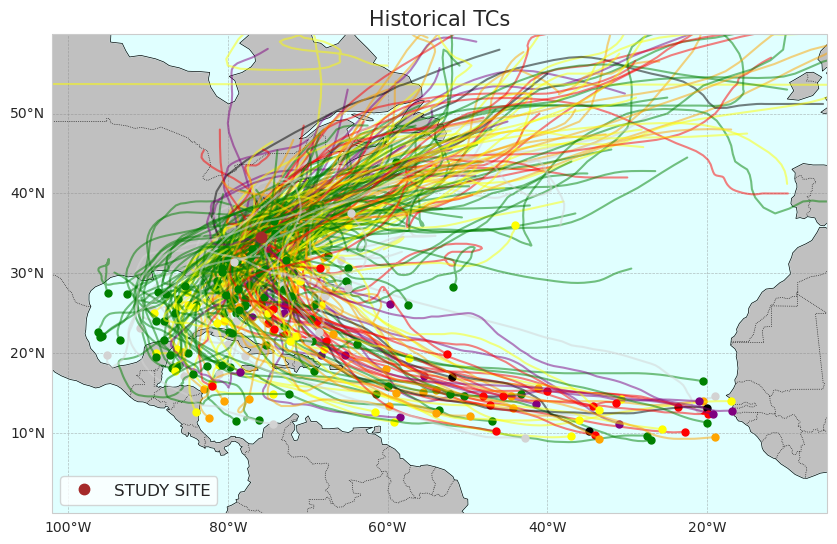

In [21]:
from utils.plotting_tcs import Plot_TCs_HistoricalTracks_Category
import matplotlib.pyplot as plt

lon1, lon2 = -102+360, -5+360
lat1, lat2 = 0, 60
path_figs = "outputs/Figures"

ax = Plot_TCs_HistoricalTracks_Category(
    tcs_sel, tcs_sel_params.category,
    lon1, lon2, lat1, lat2,
    lon_lat[0], lon_lat[1], r1,
)

plt.savefig(op.join(path_figs, 'TCs_Historical.png'), dpi=300, bbox_inches='tight')

Text(0.5, 0, 'Month')

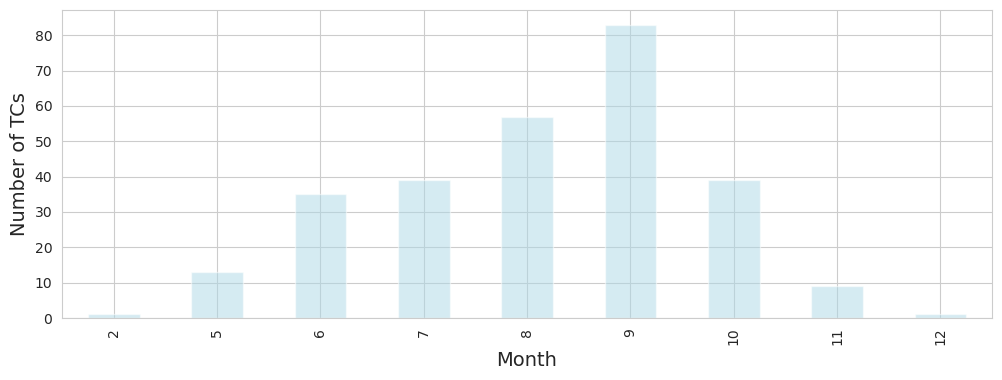

In [22]:
tcs_sel_params['month'] =  tcs_sel_params.dmin_date.dt.month
tcs_sel_params.to_dataframe().groupby('month').count().index_in.plot.bar(figsize = (12, 4), color = 'lightblue', alpha = .5)
plt.ylabel('Number of TCs', fontsize = 14)
plt.xlabel('Month', fontsize = 14)

## Severe TCs
The static plot below shows all the severe TCs in the vicinity of Palau colored by its category.
Severe TCs are defined here as those having a category equal or larger than 3

In [23]:
tcs_sel_params_severe = tcs_sel_params.where(tcs_sel_params.category >=3, drop=True)
tcs_sel_severe = tcs_sel.sel(storm=tcs_sel_params_severe.storm)

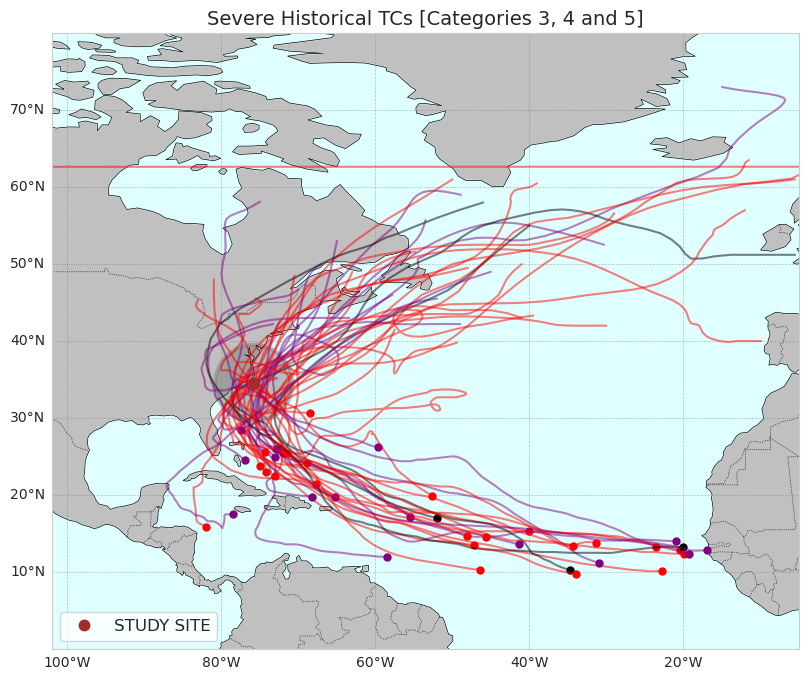

In [24]:
lon1, lon2 = -102+360, -5+360
lat1, lat2 = 0, 80
ax = Plot_TCs_HistoricalTracks_Category(
    tcs_sel_severe, tcs_sel_params_severe.category,
    lon1, lon2, lat1, lat2,
    lon_lat[0], lon_lat[1], r1,
)
ax.set_title('Severe Historical TCs [Categories 3, 4 and 5]', fontsize = 14)

plt.savefig(op.join(path_figs, 'F8_TCs_Historical_Severe.png'), dpi=300, bbox_inches='tight')

## Count TCs by Category


The bar plot below displays the TC count per category in the whole record and also to the record limited to 1979 and after.

In [25]:
u, c = np.unique(tcs_sel_params.category, return_counts=True)

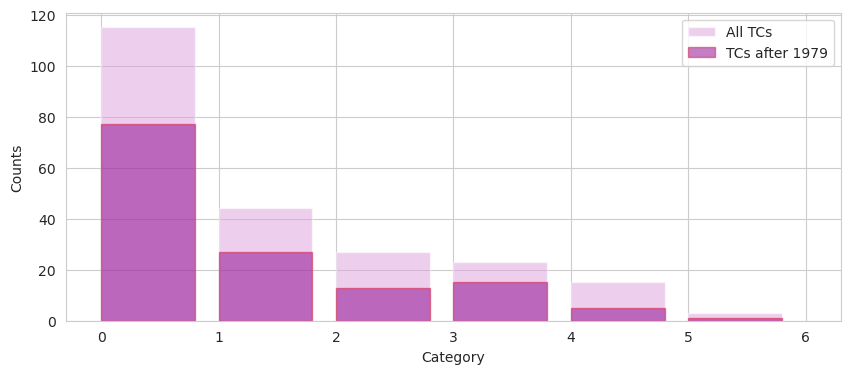

In [26]:
fig, ax = plt.subplots(1, figsize=(10, 4))
ax.grid(zorder = -1)
tcs_sel_params.category.plot.hist(bins=range(7), ax=ax, color='plum', alpha=0.5, edgecolor= None, width = .8, linewidth=1, label = 'All TCs')
tcs_sel_params.where(tcs_sel_params.dmin_date.dt.year >=1979, 
                     drop = True).category.plot.hist(bins=range(7), ax=ax, 
                                                     color='darkmagenta', alpha=0.5, edgecolor='crimson', width = .8, linewidth=1, label = 'TCs after 1979')
ax.set_xlabel('Category')
ax.set_ylabel('Counts')

ax.legend()

The following bar plot displays the TC count per year and per category, as well as the trend.

The grey color represent those TCs in the record where no pressure or wind information is available to determine the corresponding category.

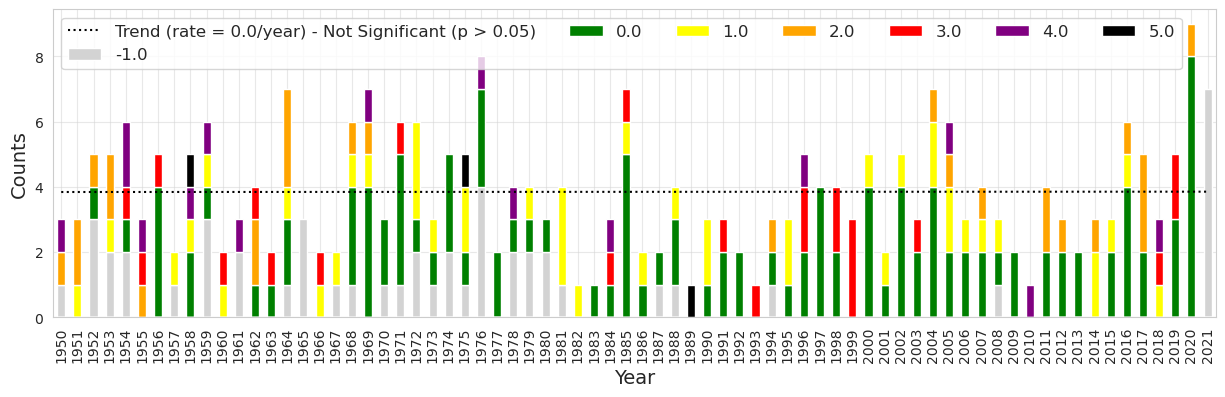

In [27]:
from utils.plotting_tcs import plot_bar_probs, plot_tc_categories_trend
plot_tc_categories_trend(tcs_sel_params)
plt.savefig(op.join(path_figs, 'TCs_Historical_bars_category.png'), dpi=300, bbox_inches='tight')

The plot below shows the trend of the number of TCs per year over time.

(<Figure size 1500x400 with 1 Axes>, <Axes: ylabel='Number TCs'>)

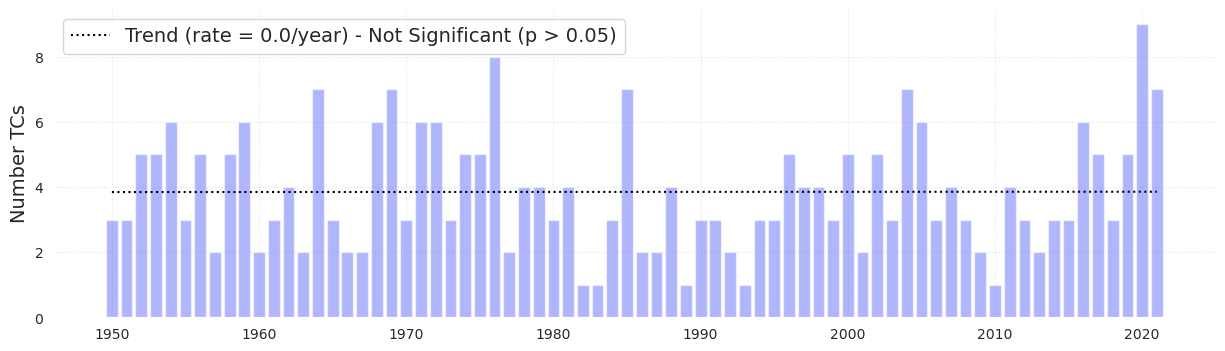

In [28]:
time = tcs_sel_params.dmin_date.dt.year.values
u, cu = np.unique(time, return_counts=True)
plot_bar_probs(x = u, y = cu, figsize= (15, 4), trendline = True,
               y_label =  'Number TCs')

The plot below shows the trend of the number of severe TCs per year over time.

(<Figure size 1500x400 with 1 Axes>, <Axes: ylabel='Number of severe TCs'>)

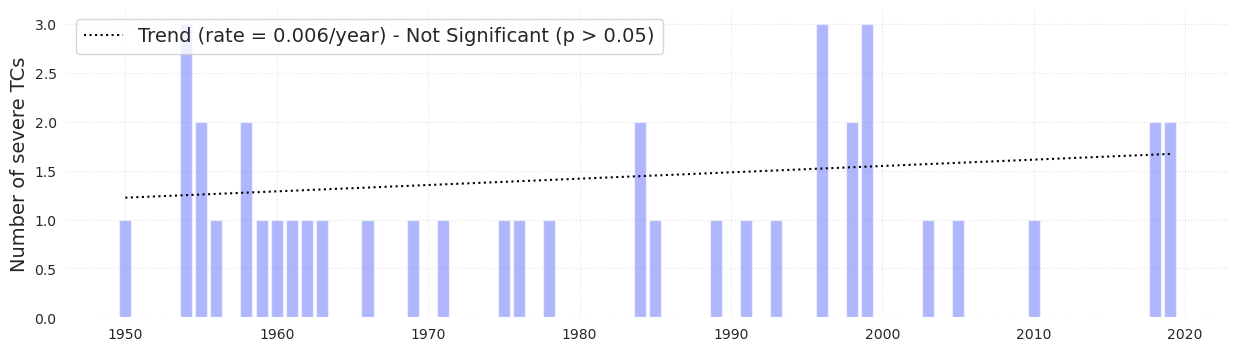

In [29]:
tcs_sel_severe_params = tcs_sel_params.where(tcs_sel_params.category >=3, drop = True)
time = tcs_sel_severe_params.dmin_date.dt.year.values
u, cu = np.unique(time, return_counts=True)
plot_bar_probs(x = u, y = cu, figsize= (15, 4), trendline = True,
               y_label =  'Number of severe TCs')

To showcase the spatial distribution of the TC tracks for the different categories, a map is shown below representing all the TCs in the record for each category.

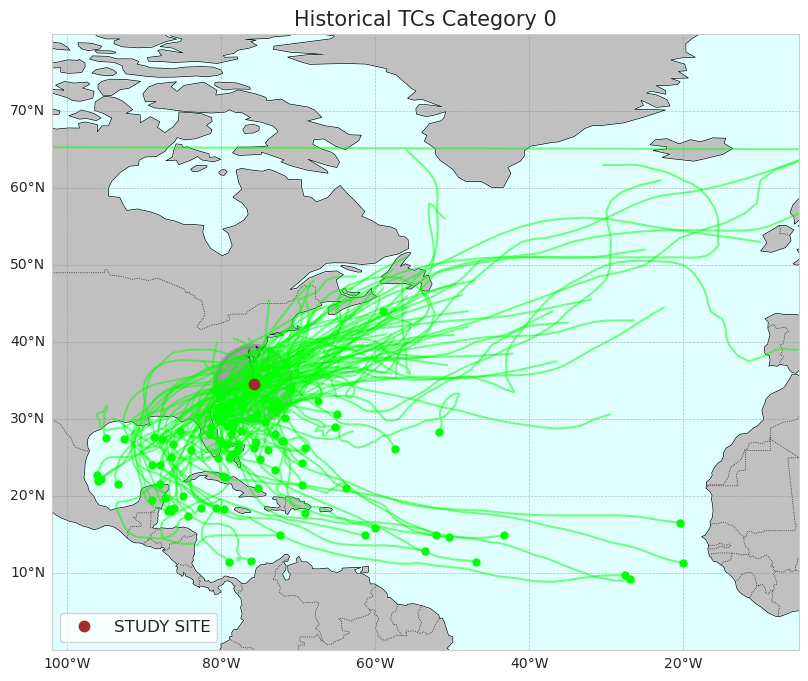

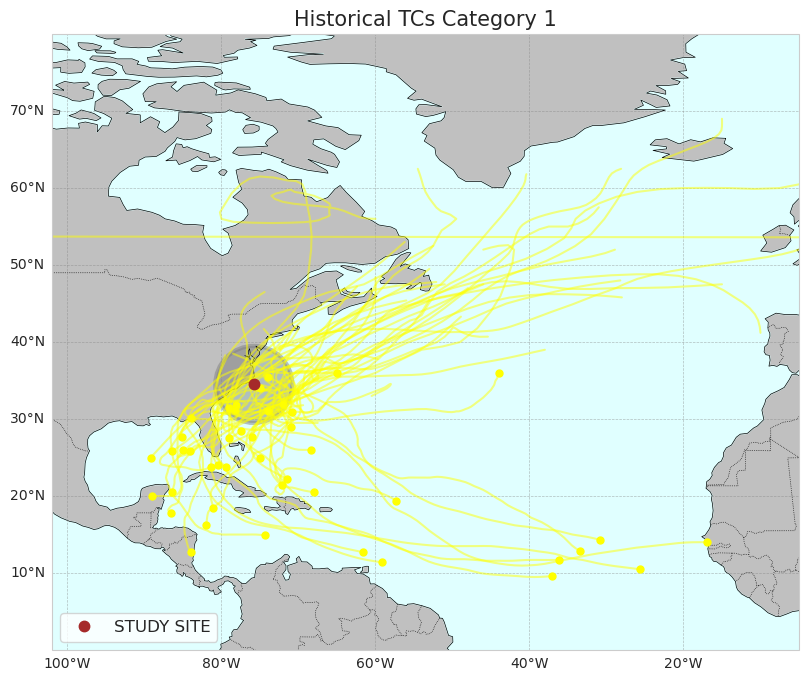

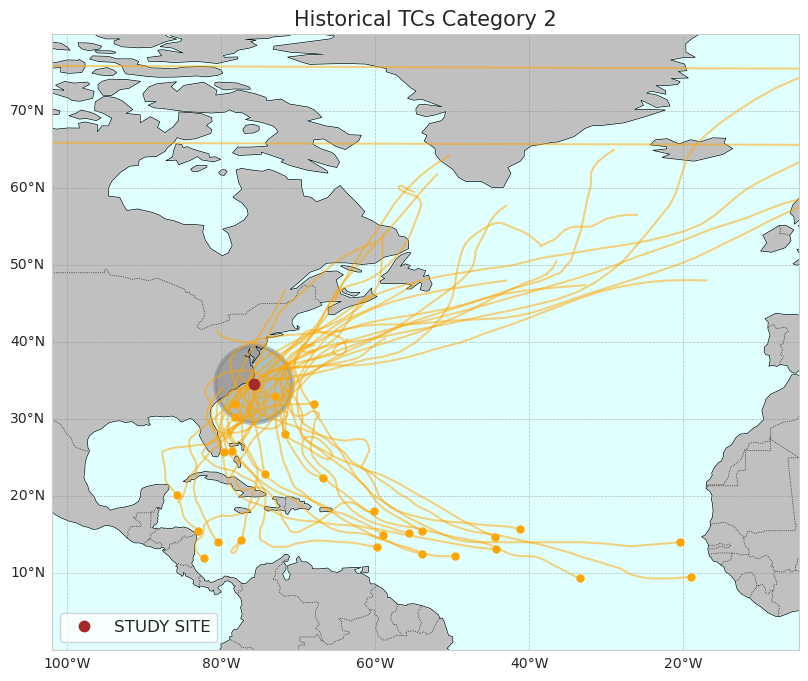

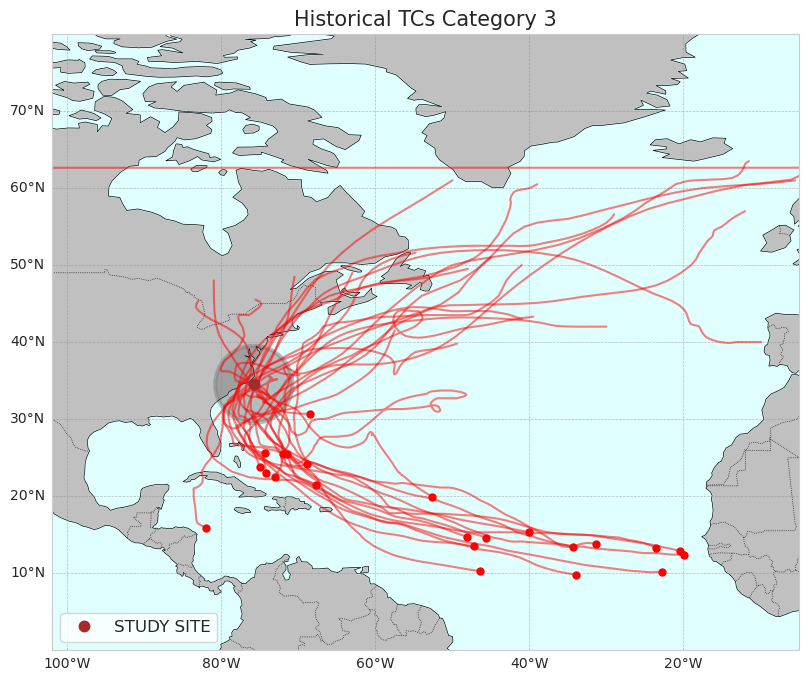

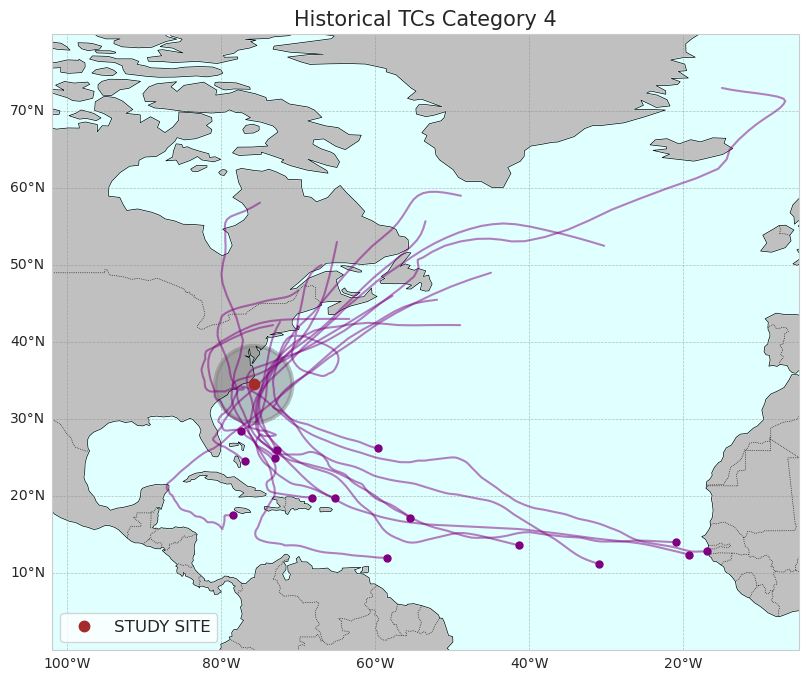

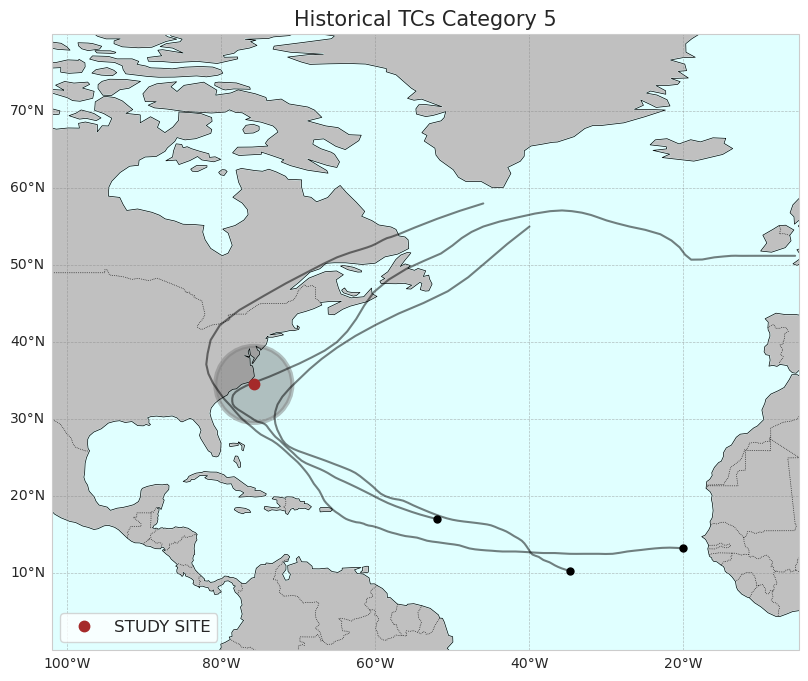

In [48]:
for category in np.arange(0, 6, 1):

    tcs_cat = tcs_sel.where(tcs_sel_params.category == category, drop = True)
    tcs_cat_params = tcs_sel_params.where(tcs_sel_params.category == category, drop = True)

    # r1
    ax = Plot_TCs_HistoricalTracks_Category(
        tcs_cat, tcs_cat_params.category,
        lon1, lon2, lat1, lat2,
        lon_lat[0], lon_lat[1], r1,
    )
    ax.set_title(f'Historical TCs Category {category}', fontsize=15)

### Generate table
Table sumarizing different metrics of the data analyzed in the plots above
Number of TCs for each category

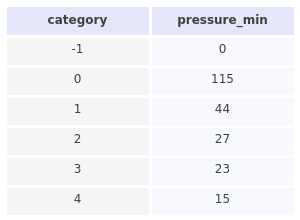

Mean TCs per year:  3.1527777777777777
Mean number of severe TCs per year:  1.41


In [30]:
from utils.tables import plot_df_table
df_tcs = tcs_sel_params.to_dataframe()
df_tcs['year'] = df_tcs.dmin_date.dt.year
df_t = df_tcs.groupby('category').count()[['pressure_min']]
fig = plot_df_table(df_t, figsize = (300, 220))

mean_tcs_per_year = df_tcs.groupby(df_tcs['dmin_date'].dt.year)['pressure_min'].count()

df_sev = df_tcs.loc[df_tcs['category'] >=3]
mean_tcs_per_year_sev = df_sev.groupby(df_sev['dmin_date'].dt.year)['pressure_min'].count()

print('Mean TCs per year: ', np.nanmean(mean_tcs_per_year))
print('Mean number of severe TCs per year: ', np.round(np.nanmean(mean_tcs_per_year_sev), 2))

##  **2. STORM SELECTION**

>### 🌀 **Hurricane Isaias (2020)**
>
>  **Peak Intensity:**  
> Category 1 hurricane  
>  • Maximum sustained winds: ~85 mph (140 km/h)  
>  • Minimum pressure: ~987 hPa
> 
>**Impact Period:**  
> July 30 – August 5, 2020 
>
>**Notable:**  
>  - Made landfall near Ocean Isle Beach, North Carolina (Aug 3, 2020).  
>  - Produced widespread power outages (over 3 million customers).  
>  - Generated numerous tornadoes along the U.S. East Coast.  
>  - Caused at least 18 deaths and ~$5 billion in damages across the Caribbean, U.S., and Canada.  


### Wave Buoys Location for Validation

In [31]:
import time

In [32]:
lon_41013, lat_41013 = 360 - 77.7640, 33.4410
lon_41025, lat_41025 = 360 - 75.4540, 35.0100
lon_44088, lat_44088 = 360 - 74.8390, 36.6120

#### Download Wave Buoys data



In [33]:
from bluemath_tk.downloaders.noaa.noaa_downloader import NOAADownloader
noaa_downloader = NOAADownloader(base_path_to_download="NOAA_data")
# =================== Buoy 41013 =================== 
buoy_41013 = noaa_downloader.download_data(
    data_type="bulk_parameters",
    load_df=True,
    buoy_id="41013",
    years=[2011,2014,2016,2018,2019,2020],
)
for col in ["WVHT"]:
    # Replace missing value codes with NaN
    buoy_41013[col] = buoy_41013[col].replace([99.0, 999.0], np.nan)

    # Wave height and periods should not be 0
    if col in ["WVHT"]:
        buoy_41013[col] = buoy_41013[col].where(buoy_41013[col] > 0, np.nan)
buoy_41013.set_index("datetime", inplace=True)
buoy_41013 = buoy_41013['WVHT'].dropna()


# =================== Buoy 41025 =================== 
buoy_41025 = noaa_downloader.download_data(
    data_type="bulk_parameters",
    load_df=True,
    buoy_id="41025",
    years=[2011,2014,2016,2018,2019,2020],
)
for col in ["WVHT"]:
    # Replace missing value codes with NaN
    buoy_41025[col] = buoy_41025[col].replace([99.0, 999.0], np.nan)

    # Wave height and periods should not be 0
    if col in ["WVHT"]:
        buoy_41025[col] = buoy_41025[col].where(buoy_41025[col] > 0, np.nan)
buoy_41025.set_index("datetime", inplace=True)
buoy_41025 = buoy_41025['WVHT'].dropna()


# =================== Buoy 44088 =================== 
buoy_44088 = noaa_downloader.download_data(
    data_type="bulk_parameters",
    load_df=True,
    buoy_id="44088",
    years=[2011,2014,2016,2018,2019,2020],
)
for col in ["WVHT"]:
    # Replace missing value codes with NaN
    buoy_44088[col] = buoy_44088[col].replace([99.0, 999.0], np.nan)

    # Wave height and periods should not be 0
    if col in ["WVHT"]:
        buoy_44088[col] = buoy_44088[col].where(buoy_44088[col] > 0, np.nan)
buoy_44088.set_index("datetime", inplace=True)
buoy_44088 = buoy_44088['WVHT'].dropna()

2025-08-28 13:54:48,165 - NOAADownloader - WARNING - Buoy 44088: No data available for year 2011
2025-08-28 13:54:49,367 - NOAADownloader - WARNING - Buoy 44088: No data available for year 2014
2025-08-28 13:54:50,284 - NOAADownloader - WARNING - Buoy 44088: No data available for year 2016
2025-08-28 13:54:51,451 - NOAADownloader - WARNING - Buoy 44088: No data available for year 2019


In [34]:
# to select tc from name and year
name_tc, year_tc = "ISAIAS", 2020
itc = np.where(
    (xds_tcs["name"].values.astype("str") == name_tc)
    & (xds_tcs.isel(date_time=0).time.dt.year.values == year_tc)
)[0]
isaias= xds_tcs.isel(storm=itc).squeeze().load()
isaias


<xarray.Dataset> Size: 557kB
Dimensions:           (date_time: 360, quadrant: 4)
Coordinates:
    time              (date_time) datetime64[ns] 3kB 2020-07-28T12:00:00 ... NaT
    lat               (date_time) float32 1kB 12.5 12.83 13.2 ... nan nan nan
    lon               (date_time) float32 1kB 306.0 304.7 303.6 ... nan nan nan
Dimensions without coordinates: date_time, quadrant
Data variables: (12/147)
    numobs            float32 4B 66.0
    sid               |S64 64B b'2020211N13306'
    season            float32 4B 2.02e+03
    number            int16 2B 26
    basin             (date_time) |S64 23kB b'NA' b'NA' b'NA' ... b'' b'' b''
    subbasin          (date_time) |S64 23kB b'NA' b'NA' b'NA' ... b'' b'' b''
    ...                ...
    reunion_gust      (date_time) float32 1kB nan nan nan nan ... nan nan nan
    reunion_gust_per  (date_time) float32 1kB nan nan nan nan ... nan nan nan
    usa_seahgt        (date_time) float32 1kB nan nan nan nan ... nan nan nan
    usa_searad        (date_time, quadrant) float32 6kB nan nan nan ... nan nan
    storm_speed       (date_time) float32 1kB 25.0 24.0 22.0 ... nan nan nan
    storm_dir         (date_time) float32 1kB 285.0 287.0 292.0 ... nan nan nan
Attributes: (12/52)
    title:                      IBTrACS - International Best Track Archive fo...
    summary:                    The intent of the IBTrACS project is to overc...
    source:                     The original data are tropical cyclone positi...
    Conventions:                ACDD-1.3
    Conventions_note:           Data are nearly CF-1.7 compliant. The sole is...
    product_version:            v04r00
    ...                         ...
    cdm_data_type:              Trajectory
    comment:                    The tracks of TCs generally look like a traje...
    nco_openmp_thread_number:   1
    NCO:                        4.4.3
    DODS.strlen:                2
    DODS.dimName:               char2

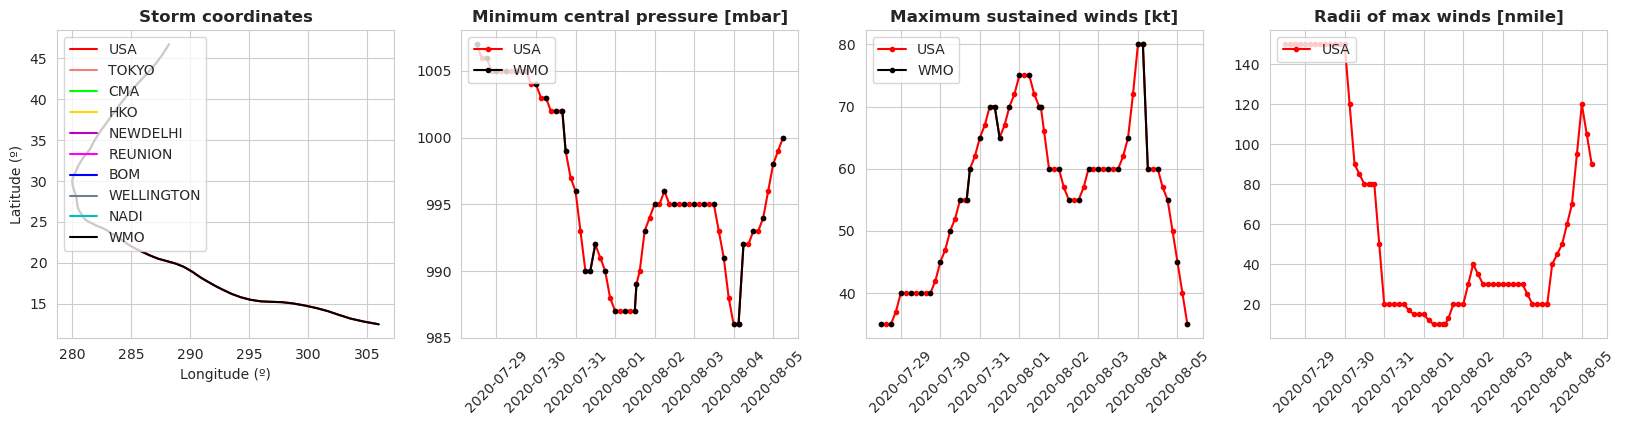

In [35]:

# storm = xr.open_dataset("outputs/ibtracs_oahu.nc").isel(storm=1)
storm_year = int(isaias.season.values)

name = str(isaias.name.values)[2:-1]
year = isaias.time[0].dt.year.values

# plot IBTrACS data
fig = check_and_plot_track_data(isaias)

In [36]:
isaias = resample_storm_6h(isaias)
isaias["lon"] = (
    ("time"),
    np.where(isaias["lon"].values < 0, isaias["lon"].values + 360, isaias["lon"].values),
)
isaias

# Are sourrounding storm to extract bulk parameters
extra_area = 12
area_isaias = [
    isaias.lon.min().values - extra_area,
    isaias.lon.max().values + extra_area,
    isaias.lat.min().values - extra_area,
    isaias.lat.max().values + extra_area,
]

t0 = time.time()

# project path
path_proj = op.join(output_path, "tc_{0}_{1}_{2}".format(itc, name, year))
if not op.isdir(path_proj):
    os.mkdir(path_proj)

tc_name = name + "_hist"
center = "WMO"

swath_resolution = 0.5
lon = np.arange(area_isaias[0], area_isaias[1], swath_resolution)
lat = np.arange(area_isaias[2], area_isaias[3], swath_resolution)

In [37]:
historic2shytcwaves_cluster(
    path_proj,
    tc_name,
    isaias,
    center,
    lon,
    lat,
    calibration=True,
    extract_bulk=True,
)

print(f"Elapsed time: {time.time() - t0} s")


st: 31, df_seg: 30
Number of segments: 28, number of swath nodes: 11700
Merging bulk envelope... 2025-08-28 13:58:36.595802
Files stored.
Elapsed time: 232.4123079776764 s


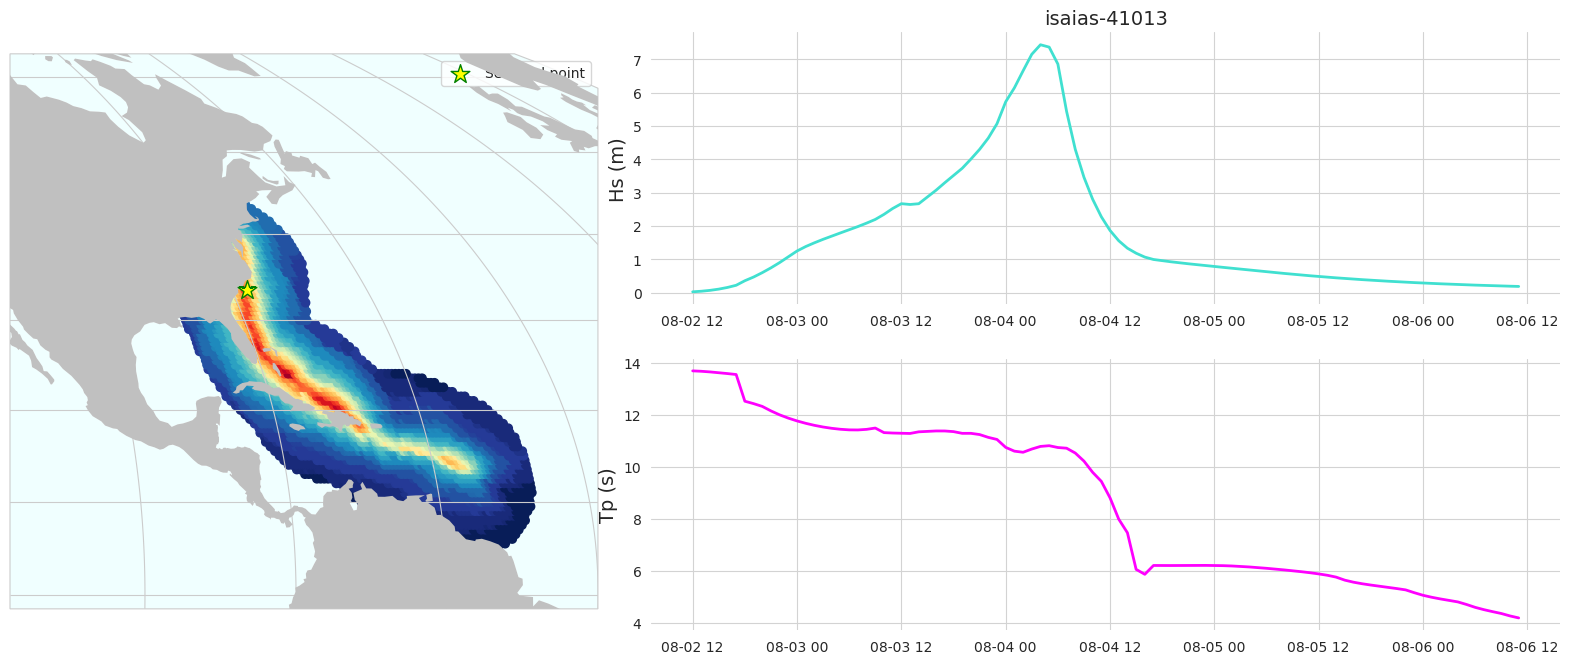

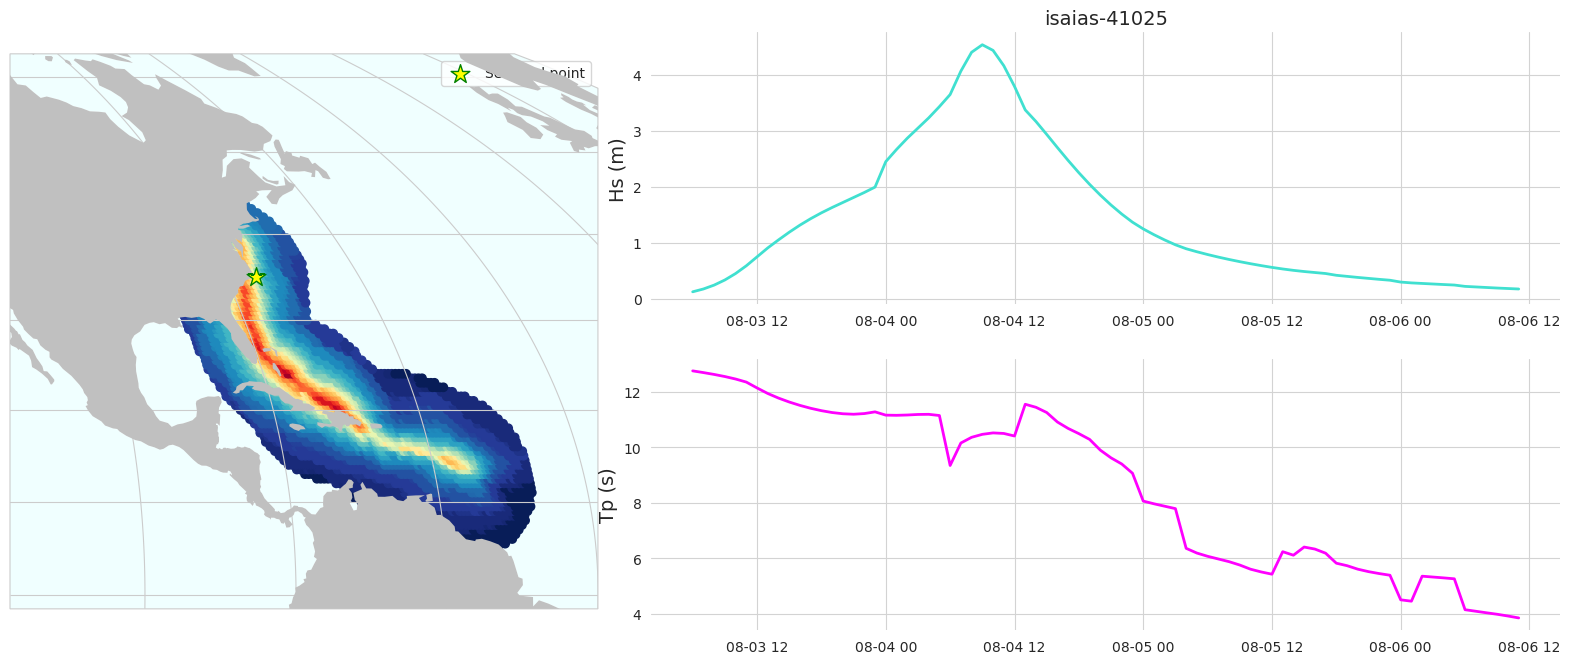

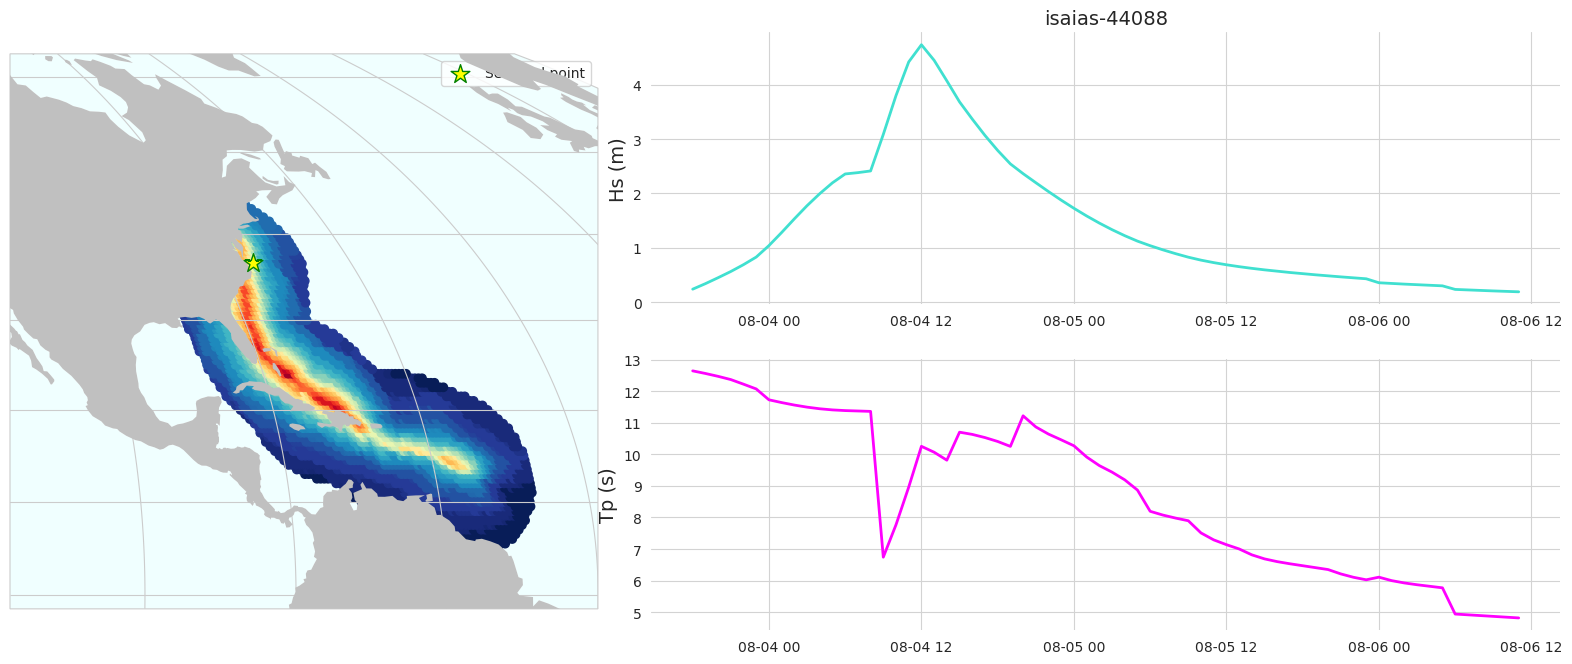

In [44]:
import importlib
import utils.plotting_tcs  # replace with actual module name
importlib.reload(utils.plotting_tcs)


xds_bulk_isaias = xr.open_dataset(op.join(path_proj, "{0}_xds_shy_bulk.nc".format(tc_name)))
xds_bulk_isaias
plot_hs_tp_point(xds_bulk_isaias, area_isaias, lon_41013, lat_41013,'isaias-41013')
plot_hs_tp_point(xds_bulk_isaias, area_isaias, lon_41025, lat_41025,'isaias-41025')
plot_hs_tp_point(xds_bulk_isaias, area_isaias, lon_44088, lat_44088,'isaias-44088')
# plot_swath_shytcwaves(isaias, xds_bulk_isaias, area_isaias , itc, path_proj, var="hswath", vmax=None)

In [45]:
xds_point_isaias_41013 = xds_bulk_isaias.isel(
    point=np.argmin(
        np.sqrt((xds_bulk_isaias.lon.values - lon_41013) ** 2 + (xds_bulk_isaias.lat.values - lat_41013) ** 2)
    )
)
xds_point_isaias_44088 = xds_bulk_isaias.isel(
    point=np.argmin(
        np.sqrt((xds_bulk_isaias.lon.values - lon_44088) ** 2 + (xds_bulk_isaias.lat.values - lat_44088) ** 2)
    )
)
xds_point_isaias_41025 = xds_bulk_isaias.isel(
    point=np.argmin(
        np.sqrt((xds_bulk_isaias.lon.values - lon_41025) ** 2 + (xds_bulk_isaias.lat.values - lat_41025) ** 2)
    )
)

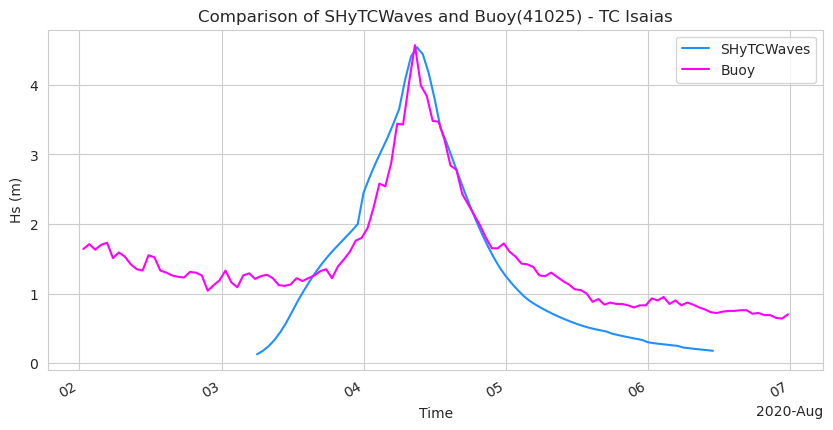

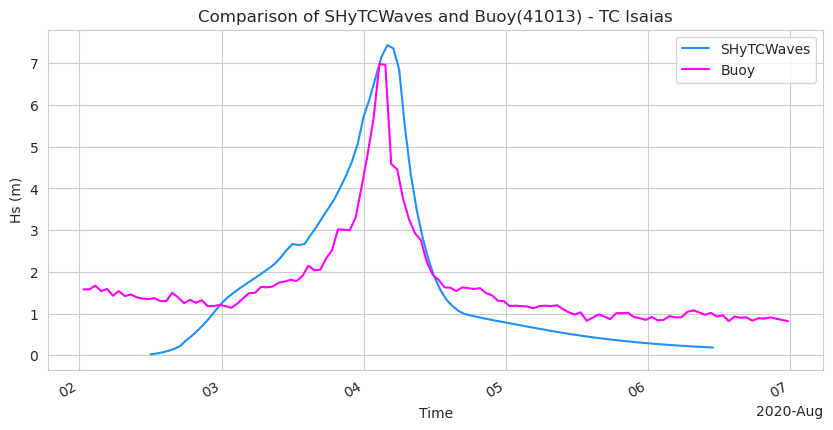

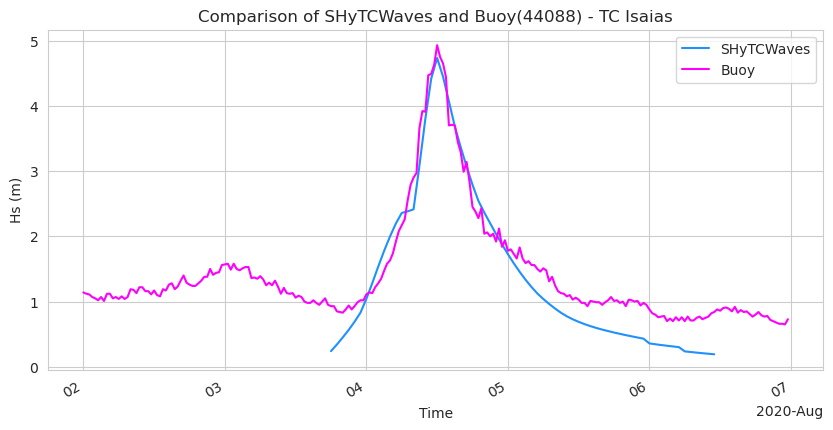

In [46]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 5))
xds_point_isaias_41025.hsbmu.plot(ax=ax, x="time", label="SHyTCWaves", color="dodgerblue")
buoy_41025.loc["2020-08-02":"2020-08-06"].plot(ax=ax, label="Buoy", color="fuchsia")
ax.legend()
ax.set_title("Comparison of SHyTCWaves and Buoy(41025) - TC Isaias")
ax.set_xlabel("Time")
ax.set_ylabel("Hs (m)")
plt.show()

fig, ax = plt.subplots(figsize=(10, 5))
xds_point_isaias_41013.hsbmu.plot(ax=ax, x="time", label="SHyTCWaves", color="dodgerblue")
buoy_41013.loc["2020-08-02":"2020-08-06"].plot(ax=ax, label="Buoy", color="fuchsia")
ax.legend()
ax.set_title("Comparison of SHyTCWaves and Buoy(41013) - TC Isaias")
ax.set_xlabel("Time")
ax.set_ylabel("Hs (m)")
plt.show()

fig, ax = plt.subplots(figsize=(10, 5))
xds_point_isaias_44088.hsbmu.plot(ax=ax, x="time", label="SHyTCWaves", color="dodgerblue")
buoy_44088.loc["2020-08-02":"2020-08-06"].plot(ax=ax, label="Buoy", color="fuchsia")
ax.legend()
ax.set_title("Comparison of SHyTCWaves and Buoy(44088) - TC Isaias")
ax.set_xlabel("Time")
ax.set_ylabel("Hs (m)")
plt.show()